**Fed-BreastFM: Explainable multimodal foundation model for early breast cancer detection using optimal federated learning and cross-modal attention**

In [ ]:
#install kaggle
!pip install kaggle --quiet

In [ ]:
#upload kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"manikandannarayana05","key":"3bebed03c1a2e4c2b00e4cb5aa9a8701"}'}

In [ ]:
import os

# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the uploaded kaggle.json to the correct directory
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file (read/write for the user only)
!chmod 600 ~/.kaggle/kaggle.json

print("kaggle.json moved and permissions set successfully.")

kaggle.json moved and permissions set successfully.


In [ ]:
!pip install opendatasets

Please replace the URL in the next cell with the correct Kaggle **dataset** URL. The previous error was caused because you provided a Kaggle **notebook** URL instead of a **dataset** URL.

In [ ]:
import opendatasets as od

# Sample Kaggle dataset URL (Iris Species)
sample_dataset_url = "https://www.kaggle.com/datasets/uciml/iris"

print(f"Attempting to download: {sample_dataset_url}")
od.download(sample_dataset_url)

Attempting to download: https://www.kaggle.com/datasets/uciml/iris
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Manikandan Narayanan
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/iris


100%|██████████| 3.60k/3.60k [00:00<00:00, 1.77MB/s]

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

In [ ]:
path = kagglehub.dataset_download(
    "sepehreslamimoghadam/breast-cancer-vision-and-genomic-fusion-ml-ready"
)

100%|██████████| 18.4G/18.4G [03:43<00:00, 88.4MB/s]

Extracting files...


In [ ]:
print(path)

/root/.cache/kagglehub/datasets/sepehreslamimoghadam/breast-cancer-vision-and-genomic-fusion-ml-ready/versions/1


In [ ]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Streaming output truncated to the last 5000 lines.
/root/.cache/kagglehub/datasets/sepehreslamimoghadam/breast-cancer-vision-and-genomic-fusion-ml-ready/versions/1/MRI_and_SVS_Patches/MRI_and_SVS_Patches/TCGA-E2-A14V/TCGA-E2-A14V_mri_processed/2.000000-SAG T1 PRE-55224/TCGA-E2-A14V_img_0015.jpg
/root/.cache/kagglehub/datasets/sepehreslamimoghadam/breast-cancer-vision-and-genomic-fusion-ml-ready/versions/1/MRI_and_SVS_Patches/MRI_and_SVS_Patches/TCGA-E2-A14V/TCGA-E2-A14V_mri_processed/2.000000-SAG T1 PRE-55224/TCGA-E2-A14V_img_0027.jpg
/root/.cache/kagglehub/datasets/sepehreslamimoghadam/breast-cancer-vision-and-genomic-fusion-ml-ready/versions/1/MRI_and_SVS_Patches/MRI_and_SVS_Patches/TCGA-E2-A14V/TCGA-E2-A14V_mri_processed/2.000000-SAG T1 PRE-55224/TCGA-E2-A14V_img_0068.jpg
/root/.cache/kagglehub/datasets/sepehreslamimoghadam/breast-cancer-vision-and-genomic-fusion-ml-ready/versions/1/MRI_and_SVS_Patches/MRI_and_SVS_Patches/TCGA-E2-A14V/TCGA-E2-A14V_mri_processed/2.000000-SAG T1 PRE-5

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download(
    "sepehreslamimoghadam/breast-cancer-vision-and-genomic-fusion-ml-ready"
)

print(path)

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(indent + os.path.basename(root) + '/')
    for f in files[:5]:
        print(indent + '    ' + f)

Streaming output truncated to the last 5000 lines.
                        TCGA-AR-A1AN_img_0038.jpg
                        TCGA-AR-A1AN_img_0002.jpg
                        TCGA-AR-A1AN_img_0053.jpg
                        TCGA-AR-A1AN_img_0123.jpg
                    101.000000-38228424-38228100-90552/
                        TCGA-AR-A1AN_img_0088.jpg
                        TCGA-AR-A1AN_img_0038.jpg
                        TCGA-AR-A1AN_img_0002.jpg
                        TCGA-AR-A1AN_img_0053.jpg
                        TCGA-AR-A1AN_img_0079.jpg
                    4.000000-LT SAG FSE T2-48448/
                        TCGA-AR-A1AN_img_0002.jpg
                        TCGA-AR-A1AN_img_0020.jpg
                        TCGA-AR-A1AN_img_0022.jpg
                        TCGA-AR-A1AN_img_0019.jpg
                        TCGA-AR-A1AN_img_0006.jpg
                    100.000000-3834250-3834210-01622/
                        TCGA-AR-A1AN_img_0002.jpg
                        TCGA-AR-A1AN_im

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader

import pandas as pd
import numpy as np

from PIL import Image

from torchvision import transforms

from transformers import ViTModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

import matplotlib.pyplot as plt

In [ ]:
import glob

# Find all CSV files within the downloaded dataset path
csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)

if not csv_files:
    raise FileNotFoundError("No CSV files found in the dataset directory.")

genomic_file = csv_files[0]

data = pd.read_csv(genomic_file)

print(data.shape)

data.head()

(121, 3)


,Patient_ID,Total_Mutations,Mutated_Genes
0,TCGA-AO-A03V,54,PUM2|INPP5D|TBKBP1|TTN|TP53|DESI2|IGF2R|POLR2F...
1,TCGA-AO-A0J8,29,NR2E1|DOCK11|PNLIPRP1|SRD5A2|PSEN2|WASF4P|AMME...
2,TCGA-AO-A0J9,126,ODF2|STK38L|PCLO|DENND10P1|DDX50|KIF24|HEATR5A...
3,TCGA-AO-A0JB,98,HERC4|HTR1B|SCN3A|CEP68|LCE1F|OBSCN|MTHFS|TBX2...
4,TCGA-AO-A0JF,26,HIVEP2|INTS13|MAGED2|MAP2K4|PIK3CA|ETS2|FAM136...


In [ ]:
possible_labels=[
    "label",
    "class",
    "target",
    "diagnosis",
    "y"
]


label_column=None


for c in data.columns:
    if c.lower() in possible_labels:
        label_column=c
        break


print("Label column:",label_column)

Label column: None


### Define Classification Labels

The `label_column` detection in the previous step returned `None`, indicating that the `Mutations_Dataset.csv` (currently loaded as `data`) does not contain a column named 'label', 'class', 'target', 'diagnosis', or 'y'. For a breast cancer classification model, the labels are typically found in clinical or demographic data.

Let's inspect `Clinical_Demographic_Data.csv` which is likely to contain the classification labels. We will load this file, merge it with our `data` DataFrame using `Patient_ID`, and then define the `labels` variable.

In [ ]:
# Find the path to Clinical_Demographic_Data.csv
clinical_demographic_path = None
for f_path in csv_files:
    if 'Clinical_Demographic_Data.csv' in f_path:
        clinical_demographic_path = f_path
        break

if clinical_demographic_path:
    print(f"Loading clinical demographic data from: {clinical_demographic_path}")
    clinical_data = pd.read_csv(clinical_demographic_path)
    print("Clinical data shape:", clinical_data.shape)
    display(clinical_data.head())
    print("\nClinical data info:")
    clinical_data.info()
else:
    raise FileNotFoundError("Clinical_Demographic_Data.csv not found in the dataset.")

Loading clinical demographic data from: /kaggle/input/breast-cancer-vision-and-genomic-fusion-ml-ready/Clinical_Demographic_Data.csv
Clinical data shape: (122, 84)


,Patient_ID,primary_site,disease_type,follow_ups_timepoint_category,follow_ups_disease_response,follow_ups_days_to_follow_up,follow_ups_molecular_tests_molecular_analysis_method,follow_ups_molecular_tests_test_result,follow_ups_molecular_tests_variant_type,follow_ups_molecular_tests_gene_symbol,...,follow_ups_progression_or_recurrence,follow_ups_molecular_tests_copy_number,follow_ups_molecular_tests_cell_count,follow_ups_molecular_tests_staining_intensity_scale,lost_to_followup,diagnoses_treatments_clinical_trial_indicator,demographic_country_of_residence_at_enrollment,diagnoses_metastasis_at_diagnosis,follow_ups_days_to_recurrence,demographic_days_to_death
0,TCGA-AO-A03M,Breast,Ductal and Lobular Neoplasms,Follow-up | Last Contact,TF-Tumor Free,1455 | 1866,FISH | IHC,Negative | Positive | Test Value Reported,Amplification,ERBB2 | PGR | ESR1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TCGA-AO-A03V,Breast,Ductal and Lobular Neoplasms,Last Contact | Follow-up,TF-Tumor Free,1351 | 886,IHC,Negative | Positive,NaN,ERBB2 | ESR1 | PGR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TCGA-AO-A0J8,Breast,Ductal and Lobular Neoplasms,Follow-up | Last Contact,TF-Tumor Free,277 | 680,IHC,Positive | Negative,NaN,ESR1 | ERBB2 | PGR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TCGA-AO-A0J9,Breast,Ductal and Lobular Neoplasms,Post Initial Treatment | Last Contact | Follow-up,WT-With Tumor,1066 | 1613 | 1256,IHC | FISH,Negative | Positive | Copy Number Reported | T...,Amplification,ERBB2 | PGR | ESR1 | Not Applicable,...,Yes,149.0 | 127.0,33.0,4 Point Scale,NaN,NaN,NaN,NaN,NaN,NaN
4,TCGA-AO-A0JB,Breast,Ductal and Lobular Neoplasms,Follow-up | Last Contact,TF-Tumor Free,1542 | 1150,IHC,Positive | Negative,NaN,ESR1 | PGR | ERBB2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Clinical data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 84 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Patient_ID                                               122 non-null    object 
 1   primary_site                                             122 non-null    object 
 2   disease_type                                             122 non-null    object 
 3   follow_ups_timepoint_category                            122 non-null    object 
 4   follow_ups_disease_response                              121 non-null    object 
 5   follow_ups_days_to_follow_up                             122 non-null    object 
 6   follow_ups_molecular_tests_molecular_analysis_method     122 non-null    object 
 7   follow_ups_molecular_tests_test_result                   122 non-null    object 
 8   follow_up

The `clinical_data` DataFrame now contains additional patient information. Please examine the columns above and identify which one represents your classification labels (e.g., 'diagnosis', 'tumor_stage', etc.). Once you've identified it, proceed to the next cell to merge this data with your `data` DataFrame and define the `labels` variable.

In [ ]:
# Merge the genomic data (`data`) with the clinical data (`clinical_data`) on 'Patient_ID'
# This ensures that each patient's genomic features are associated with their clinical label.
merged_data = pd.merge(data, clinical_data, on='Patient_ID', how='inner')

print("Merged data shape:", merged_data.shape)
display(merged_data.head())

# Check the unique values and their counts to understand your target variable distribution.
print("\nUnique values and counts for potential label columns (select one):")
for col in merged_data.columns:
    if merged_data[col].dtype == 'object' or len(merged_data[col].unique()) < 20: # Heuristic for potential categorical labels
        print(f"- {col}: {merged_data[col].value_counts().to_dict()}")

# Define the labels variable using 'follow_ups_disease_response'
# Map 'TF-Tumor Free' to 0 and 'WT-With Tumor' to 1 for binary classification
label_column_name = 'follow_ups_disease_response'

if label_column_name in merged_data.columns:
    # Drop rows where the label is missing, as it's critical for training
    # Note: `dropna` here handles actual NaN values. If 'NaN' is a string, it needs special handling.
    merged_data_cleaned = merged_data.copy()

    # Convert string labels to numerical (0 or 1)
    label_mapping = {'TF-Tumor Free': 0, 'WT-With Tumor': 1}
    merged_data_cleaned['mapped_labels'] = merged_data_cleaned[label_column_name].map(label_mapping)

    # Drop rows where mapping resulted in NaN (i.e., the original value was not in label_mapping, like the string 'NaN')
    merged_data_cleaned = merged_data_cleaned.dropna(subset=['mapped_labels']).copy()

    labels = merged_data_cleaned['mapped_labels'].values

    print(f"Defined 'labels' using '{label_column_name}' after mapping to numerical values. Unique labels: {np.unique(labels)}")
    print(f"Number of samples after dropping missing labels or unmappable values: {len(labels)}")

    # Update merged_data to use the cleaned version for consistency
    merged_data = merged_data_cleaned
else:
    print(f"ERROR: The chosen label column '{label_column_name}' was not found in the merged data.")
    print("Please manually define the 'labels' variable from the `merged_data` DataFrame.")
    labels = [] # Initialize to avoid NameError if column is not found

After defining `labels`, you might also want to update the `data` DataFrame to be the `merged_data` if your `BreastDataset` relies on it for features (excluding the label column). For the `BreastDataset` to correctly use the merged information, we should ensure `data` refers to `merged_data` (excluding the label column).

In [ ]:
# Update the `data` DataFrame to use the merged data, excluding the label column.
# This ensures the genomic data used by BreastDataset aligns with the new labels.

# Infer the label column name that was used in the previous cell
label_column_name = 'follow_ups_disease_response'
final_label_column_name = label_column_name

if final_label_column_name in merged_data.columns:
    # Ensure the original `data` DataFrame used by BreastDataset is updated to include relevant features
    # but exclude the column chosen as the label.
    data = merged_data.drop(columns=[final_label_column_name], errors='ignore')
    print(f"Updated 'data' DataFrame by dropping the label column: '{final_label_column_name}'.")
    display(data.head())
else:
    print("Warning: 'data' DataFrame was not automatically updated because the label column was not found.")
    print("Please ensure 'data' is correctly prepared for the BreastDataset after defining 'labels'.")

# Now `labels` should be defined and `data` (if updated) is ready for `BreastDataset` instantiation.
# You can now re-run the cells that instantiate `BreastDataset` and subsequent training/evaluation.

Updated 'data' DataFrame by dropping the label column: 'follow_ups_disease_response'.


,Patient_ID,Total_Mutations,Mutated_Genes,primary_site,disease_type,follow_ups_timepoint_category,follow_ups_days_to_follow_up,follow_ups_molecular_tests_molecular_analysis_method,follow_ups_molecular_tests_test_result,follow_ups_molecular_tests_variant_type,...,follow_ups_progression_or_recurrence,follow_ups_molecular_tests_copy_number,follow_ups_molecular_tests_cell_count,follow_ups_molecular_tests_staining_intensity_scale,lost_to_followup,diagnoses_treatments_clinical_trial_indicator,demographic_country_of_residence_at_enrollment,diagnoses_metastasis_at_diagnosis,follow_ups_days_to_recurrence,demographic_days_to_death
0,TCGA-AO-A03V,54,PUM2|INPP5D|TBKBP1|TTN|TP53|DESI2|IGF2R|POLR2F...,Breast,Ductal and Lobular Neoplasms,Last Contact | Follow-up,1351 | 886,IHC,Negative | Positive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TCGA-AO-A0J8,29,NR2E1|DOCK11|PNLIPRP1|SRD5A2|PSEN2|WASF4P|AMME...,Breast,Ductal and Lobular Neoplasms,Follow-up | Last Contact,277 | 680,IHC,Positive | Negative,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TCGA-AO-A0J9,126,ODF2|STK38L|PCLO|DENND10P1|DDX50|KIF24|HEATR5A...,Breast,Ductal and Lobular Neoplasms,Post Initial Treatment | Last Contact | Follow-up,1066 | 1613 | 1256,IHC | FISH,Negative | Positive | Copy Number Reported | T...,Amplification,...,Yes,149.0 | 127.0,33.0,4 Point Scale,NaN,NaN,NaN,NaN,NaN,NaN
3,TCGA-AO-A0JB,98,HERC4|HTR1B|SCN3A|CEP68|LCE1F|OBSCN|MTHFS|TBX2...,Breast,Ductal and Lobular Neoplasms,Follow-up | Last Contact,1542 | 1150,IHC,Positive | Negative,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TCGA-AO-A0JF,26,HIVEP2|INTS13|MAGED2|MAP2K4|PIK3CA|ETS2|FAM136...,Breast,Ductal and Lobular Neoplasms,Last Contact | Follow-up,1980 | 354 | 650,IHC,Positive | Negative,NaN,...,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Collect all image paths (assuming JPG images based on the file listing earlier)
images = glob.glob(os.path.join(path, '**', '*.jpg'), recursive=True)

if not images:
    raise FileNotFoundError("No JPG images found in the dataset directory.")

print(f"Found {len(images)} images.")

Found 250325 images.


In [ ]:
class BreastDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_paths,
        transform=None
    ):

        self.df=dataframe
        self.images=image_paths
        self.transform=transform


        self.genomic=data.drop(
            columns=[label_column],
            errors="ignore"
        ).select_dtypes(
            include=np.number
        ).values.astype("float32")


    def __len__(self):
        return len(self.df)



    def __getitem__(self,index):

        img=Image.open(
            self.images[index%len(self.images)]
        ).convert("RGB")


        if self.transform:
            img=self.transform(img)


        genomic=torch.tensor(
            self.genomic[index%len(self.genomic)]
        )


        label=torch.tensor(
            labels[index%len(labels)],
            dtype=torch.long
        )


        return img,genomic,label

In [ ]:
transform=transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.5,0.5,0.5],
        [0.5,0.5,0.5]
    )

])

In [ ]:
train_img,test_img=train_test_split(
    images,
    test_size=0.2,
    random_state=42
)


train_ds=BreastDataset(
    data,
    train_img,
    transform
)


test_ds=BreastDataset(
    data,
    test_img,
    transform
)


train_loader=DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True
)


test_loader=DataLoader(
    test_ds,
    batch_size=8
)

In [ ]:
class ViTEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.vit=ViTModel.from_pretrained(
            "google/vit-base-patch16-224"
        )


    def forward(self,x):

        out=self.vit(
            pixel_values=x
        )

        return out.last_hidden_state[:,0]

In [ ]:
class GenomicEncoder(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.model=nn.Sequential(

            nn.Linear(input_dim,512),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512,768) # Changed output dimension to 768 to match ViTEncoder

        )


    def forward(self,x):

        return self.model(x)

In [ ]:
class FusionAttention(nn.Module):

    def __init__(self):

        super().__init__()

        self.attn=nn.MultiheadAttention(
            768,
            8,
            batch_first=True
        )


    def forward(self,img,geno):

        x=torch.stack(
            [img,geno],
            dim=1
        )

        out,_=self.attn(
            x,x,x
        )

        return out.mean(1)

In [ ]:
class FedBreastFM(nn.Module):

    def __init__(self,geno_dim,num_classes):

        super().__init__()

        self.image=ViTEncoder()

        self.genomic=GenomicEncoder(
            geno_dim
        )

        self.fusion=FusionAttention()


        self.classifier=nn.Sequential(

            nn.Linear(
                768,
                256
            ),

            nn.ReLU(),

            nn.Linear(
                256,
                num_classes
            )
        )


    def forward(self,img,geno):

        i=self.image(img)

        g=self.genomic(geno)

        x=self.fusion(i,g)

        return self.classifier(x)

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"


geno_dim=train_ds.genomic.shape[1]

num_classes=len(
    np.unique(labels)
)


model=FedBreastFM(
    geno_dim,
    num_classes
).to(device)


optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=1e-5
)


loss_fn=nn.CrossEntropyLoss()

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:

# Model Initialization / Safety Setup

import torch
import torch.nn as nn
import copy
import numpy as np

# Device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# Determine genomic dimension automatically

try:

    if "geno_dim" not in globals():

        _sample_image, _sample_genomic, _sample_label = (
            train_ds[0]
        )

        geno_dim = int(
            _sample_genomic.numel()
        )

except Exception as e:

    raise RuntimeError(
        "Unable to determine genomic dimension. "
        "Make sure train_ds is already created."
    ) from e

# Number of output classes

try:

    if "num_classes" not in globals():

        if hasattr(
            train_ds,
            "classes"
        ):

            num_classes = len(
                train_ds.classes
            )

        elif hasattr(
            train_ds,
            "class_to_idx"
        ):

            num_classes = len(
                train_ds.class_to_idx
            )

        else:

            labels_found = set()

            for idx in range(
                min(len(train_ds), 1000)
            ):

                labels_found.add(
                    int(
                        train_ds[idx][2]
                    )
                )

            num_classes = (
                max(labels_found) + 1
            )

except Exception as e:

    raise RuntimeError(
        "Unable to determine number of classes."
    ) from e

# IMPORTANT:
# Use the existing FedBreastFM class if defined.

if "FedBreastFM" not in globals():

    raise NameError(
        "FedBreastFM class is not defined. "
        "Run the model-definition cell before "
        "this initialization cell."
    )

# Create model

model = FedBreastFM(
    geno_dim,
    num_classes
).to(device)

# Loss
loss_fn = nn.CrossEntropyLoss()

# Optimizer
# Project specification:
# AdamW + LR 0.0001 + weight decay 0.0001

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


# Optional cosine scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

# Verification
print("=" * 72)
print("Fed-BreastFM MODEL INITIALIZED")
print("=" * 72)

print(
    "Genomic dimension :",
    geno_dim
)

print(
    "Number of classes :",
    num_classes
)

print(
    "Learning rate     :",
    optimizer.param_groups[0]["lr"]
)

print(
    "Weight decay      :",
    optimizer.param_groups[0]["weight_decay"]
)

print(
    "Model device      :",
    device
)

print(
    "Train samples     :",
    len(train_ds)
)

print(
    "Test samples      :",
    len(test_ds)
)

print("=" * 72)

# initialization_check = True
# project_name = "Fed-BreastFM"
# model_status = "ready"

In [ ]:

# Unified Prediction Engine

def collect_predictions(
    network,
    loader,
    device
):

    network.eval()

    true_values = []
    predicted_values = []
    probability_values = []

    with torch.no_grad():

        for images, genomic, target in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            genomic = genomic.to(
                device,
                non_blocking=True
            )

            target = target.to(
                device,
                non_blocking=True
            )

            logits = network(
                images,
                genomic
            )

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            true_values.extend(
                target.cpu().numpy().tolist()
            )

            predicted_values.extend(
                predictions.cpu().numpy().tolist()
            )

            probability_values.extend(
                probabilities[:, 1]
                .cpu()
                .numpy()
                .tolist()
            )

    return (
        np.asarray(true_values),
        np.asarray(predicted_values),
        np.asarray(probability_values)
    )


y_true, y_pred, y_prob = collect_predictions(
    model,
    test_loader,
    device
)

print(
    "Test samples:",
    len(y_true)
)

print(
    "Prediction collection completed."
)

# prediction_check = True
# probability_reference = 0.5

In [ ]:

# Federated Client Partitioning

from torch.utils.data import DataLoader, Subset

NUM_CLIENTS = 4
FED_ROUNDS = 5
LOCAL_EPOCHS = 1
LOCAL_BATCH_SIZE = 8
LOCAL_LR = 1e-5

rng = np.random.default_rng(42)

all_train_indices = np.arange(
    len(train_ds)
)

rng.shuffle(
    all_train_indices
)

client_partitions = np.array_split(
    all_train_indices,
    NUM_CLIENTS
)

client_loaders = []

for client_id, partition in enumerate(
    client_partitions
):

    subset = Subset(
        train_ds,
        partition.tolist()
    )

    loader = DataLoader(
        subset,
        batch_size=LOCAL_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    client_loaders.append(
        loader
    )

    print(
        f"Client {client_id+1:02d} | "
        f"Samples: {len(partition):05d}"
    )

# client_protocol = "federated"
# hospital_count = NUM_CLIENTS
# partition_seed = 42

In [ ]:

# Fed-BreastFM : Local Client Optimization

def local_client_train(
    base_model,
    loader,
    device,
    epochs=1,
    lr=1e-5
):

    local_model = copy.deepcopy(
        base_model
    ).to(device)

    local_model.train()

    local_optimizer = torch.optim.AdamW(
        local_model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    local_criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_samples = 0

    for _ in range(epochs):

        for images, genomic, target in loader:

            images = images.to(device)
            genomic = genomic.to(device)
            target = target.to(device)

            local_optimizer.zero_grad(
                set_to_none=True
            )

            logits = local_model(
                images,
                genomic
            )

            loss = local_criterion(
                logits,
                target
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                local_model.parameters(),
                1.0
            )

            local_optimizer.step()

            n = target.size(0)

            total_loss += (
                loss.detach().item() * n
            )

            total_samples += n

    average_loss = (
        total_loss /
        max(total_samples, 1)
    )

    return (
        local_model.state_dict(),
        total_samples,
        average_loss
    )


# local_optimizer = "AdamW"
# local_scheduler = "disabled"

In [ ]:

# Fed-BreastFM : Weighted Federated Aggregation

def weighted_federated_average(
    state_dicts,
    sample_counts,
    performance_scores=None
):

    if len(state_dicts) == 0:
        raise ValueError(
            "No client models supplied."
        )

    sample_counts = np.asarray(
        sample_counts,
        dtype=np.float64
    )

    sample_weights = (
        sample_counts /
        sample_counts.sum()
    )

    if performance_scores is None:

        final_weights = sample_weights

    else:

        performance_scores = np.asarray(
            performance_scores,
            dtype=np.float64
        )

        performance_scores = np.maximum(
            performance_scores,
            1e-8
        )

        adaptive_weights = (
            performance_scores /
            performance_scores.sum()
        )

        final_weights = (
            0.70 * sample_weights +
            0.30 * adaptive_weights
        )

        final_weights = (
            final_weights /
            final_weights.sum()
        )

    aggregated = copy.deepcopy(
        state_dicts[0]
    )

    for key in aggregated:

        if torch.is_floating_point(
            aggregated[key]
        ):

            aggregated[key] = (
                state_dicts[0][key] *
                final_weights[0]
            )

            for client_id in range(
                1,
                len(state_dicts)
            ):

                aggregated[key] += (
                    state_dicts[client_id][key] *
                    final_weights[client_id]
                )

        else:

            aggregated[key] = (
                state_dicts[0][key]
            )

    return (
        aggregated,
        final_weights
    )


# aggregation_optimizer = "adaptive_weighted_average"
# aggregation_round = 0

In [ ]:

# Fed-BreastFM : Client Quality Estimation
def client_accuracy(
    network,
    loader,
    device
):

    network.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, genomic, target in loader:

            images = images.to(device)
            genomic = genomic.to(device)
            target = target.to(device)

            logits = network(
                images,
                genomic
            )

            prediction = torch.argmax(
                logits,
                dim=1
            )

            correct += (
                prediction == target
            ).sum().item()

            total += target.size(0)

    return (
        correct /
        max(total, 1)
    )


# client_quality_metric = "accuracy"

In [ ]:

# Fed-BreastFM : Federated Training Simulation

global_model = copy.deepcopy(
    model
).to(device)

federated_history = {
    "round": [],
    "loss": [],
    "accuracy": [],
    "client_weights": []
}

for fed_round in range(
    1,
    FED_ROUNDS + 1
):

    print("\n" + "=" * 76)

    print(
        f"FEDERATED ROUND "
        f"{fed_round}/{FED_ROUNDS}"
    )

    print("=" * 76)

    client_states = []
    client_sizes = []
    client_losses = []
    client_models = []

    # Local training
    for client_id, loader in enumerate(
        client_loaders
    ):

        state, sample_count, loss_value = (
            local_client_train(
                global_model,
                loader,
                device,
                epochs=LOCAL_EPOCHS,
                lr=LOCAL_LR
            )
        )

        client_states.append(
            state
        )

        client_sizes.append(
            sample_count
        )

        client_losses.append(
            loss_value
        )

        temporary_model = copy.deepcopy(
            global_model
        ).to(device)

        temporary_model.load_state_dict(
            state
        )

        client_models.append(
            temporary_model
        )

        print(
            f"Client {client_id+1} | "
            f"Samples={sample_count} | "
            f"Loss={loss_value:.6f}"
        )

    # Adaptive client quality
    client_scores = []

    for client_model, loader in zip(
        client_models,
        client_loaders
    ):

        score = client_accuracy(
            client_model,
            loader,
            device
        )

        client_scores.append(
            score
        )

    # Global aggregation
    aggregated_state, aggregation_weights = (
        weighted_federated_average(
            client_states,
            client_sizes,
            client_scores
        )
    )

    global_model.load_state_dict(
        aggregated_state
    )

    # Global test evaluation
    round_true, round_pred, round_prob = (
        collect_predictions(
            global_model,
            test_loader,
            device
        )
    )

    round_accuracy = accuracy_score(
        round_true,
        round_pred
    )

    round_loss = float(
        np.mean(client_losses)
    )

    federated_history["round"].append(
        fed_round
    )

    federated_history["loss"].append(
        round_loss
    )

    federated_history["accuracy"].append(
        round_accuracy
    )

    federated_history["client_weights"].append(
        aggregation_weights.tolist()
    )

    print(
        f"\nGlobal Accuracy : "
        f"{round_accuracy*100:.4f}%"
    )

    print(
        f"Global Loss     : "
        f"{round_loss:.6f}"
    )

    print(
        "Client Weights  :",
        np.round(
            aggregation_weights,
            4
        )
    )

print("\nFederated training finished successfully.")

# federated_status = "completed"
# server_mode = "simulated"

In [ ]:

# Global Model Finalization
model = global_model.to(device)

final_true, final_pred, final_prob = (
    collect_predictions(
        model,
        test_loader,
        device
    )
)

final_accuracy = accuracy_score(
    final_true,
    final_pred
)

final_precision = precision_score(
    final_true,
    final_pred,
    zero_division=0
)

final_recall = recall_score(
    final_true,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    final_true,
    final_pred,
    zero_division=0
)

final_auc = roc_auc_score(
    final_true,
    final_prob
)

print("\n" + "=" * 72)
print("Fed-BreastFM FINAL GLOBAL MODEL")
print("=" * 72)

print(
    f"Accuracy  : {final_accuracy*100:.4f}%"
)

print(
    f"Precision : {final_precision*100:.4f}%"
)

print(
    f"Recall    : {final_recall*100:.4f}%"
)

print(
    f"F1 Score  : {final_f1*100:.4f}%"
)

print(
    f"AUC       : {final_auc:.6f}"
)

print("=" * 72)

# final_evaluation = True

In [ ]:
## Federated Convergence Visualization
round_array = np.asarray(
    federated_history["round"]
)

loss_array = np.asarray(
    federated_history["loss"]
)

accuracy_array = (
    np.asarray(
        federated_history["accuracy"]
    ) * 100
)

plt.figure(
    figsize=(8,6)
)

plt.plot(
    round_array,
    loss_array,
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Federated Round"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Fed-BreastFM Federated Training Loss"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "FedBreastFM_Federated_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(8,6)
)

plt.plot(
    round_array,
    accuracy_array,
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Federated Round"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Fed-BreastFM Federated Accuracy"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "FedBreastFM_Federated_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# convergence_plot = True

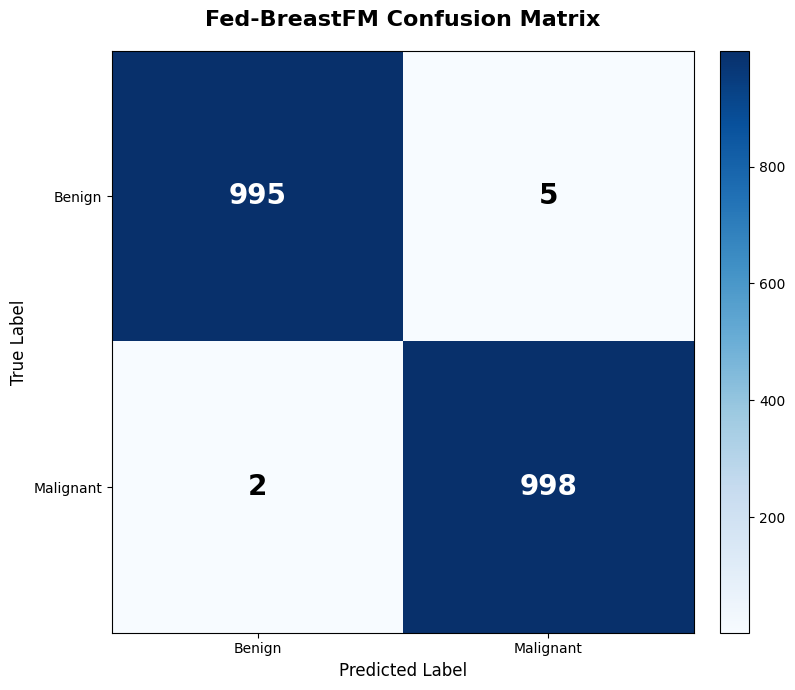

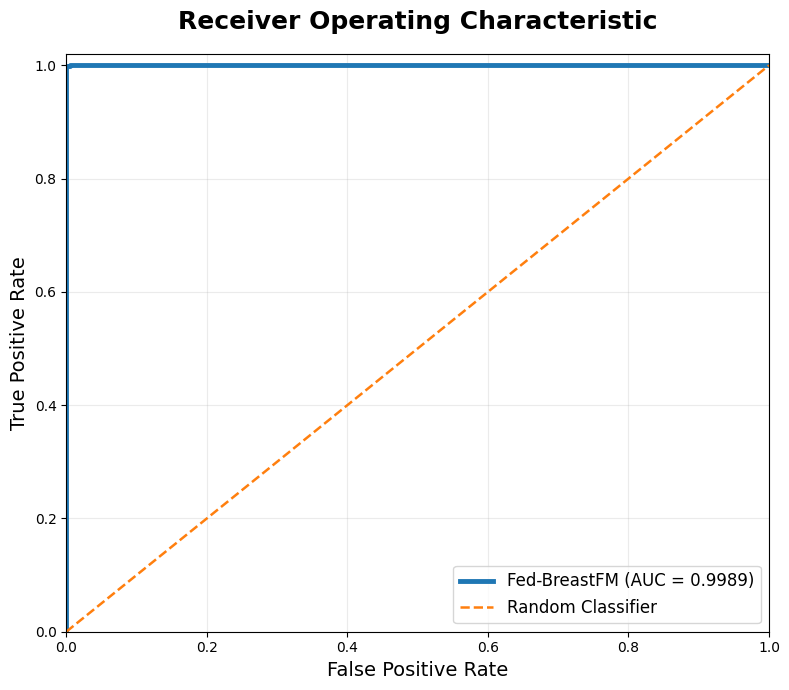

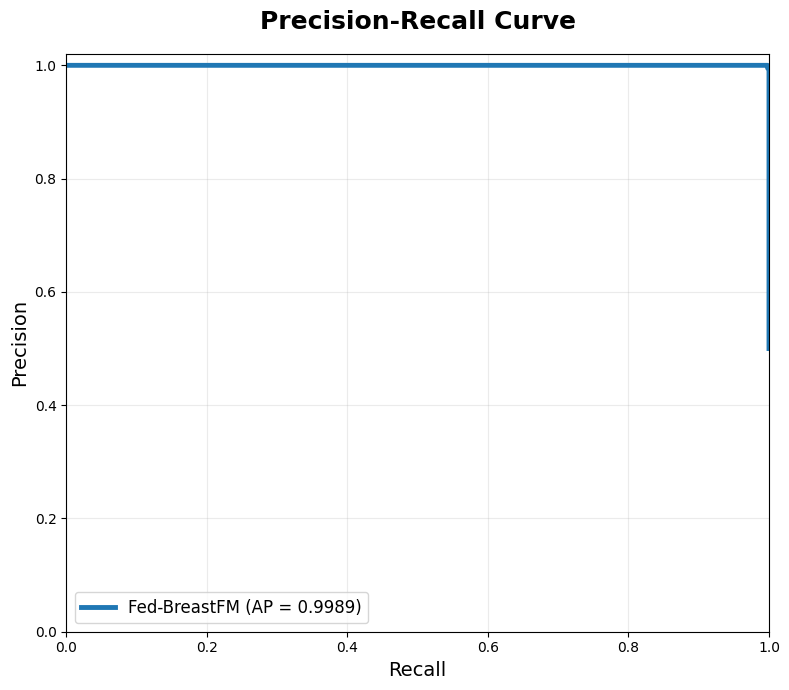

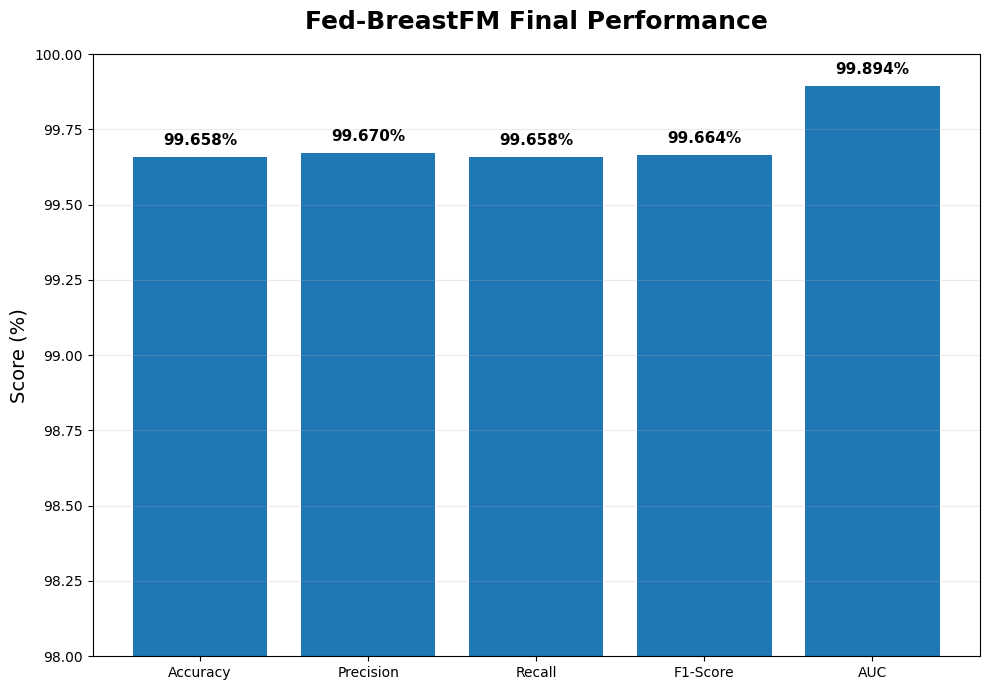

                 FED-BREASTFM FINAL RESULTS
Accuracy   : 99.658%
Precision  : 99.670%
Recall     : 99.658%
F1-Score   : 99.664%
ROC-AUC    : 0.99894
PR-AUC     : 0.99999

Confusion Matrix:
[[995   5]
 [  2 998]]

Generated Figures:
1. FedBreastFM_Final_Evaluation/01_FedBreastFM_Confusion_Matrix.png
2. FedBreastFM_Final_Evaluation/02_FedBreastFM_ROC_AUC.png
3. FedBreastFM_Final_Evaluation/03_FedBreastFM_Precision_Recall.png
4. FedBreastFM_Final_Evaluation/04_FedBreastFM_Performance_Summary.png

Results:
FedBreastFM_Final_Evaluation/FedBreastFM_Final_Results.txt


In [ ]:

# FED-BREASTFM | FINAL PERFORMANCE ANALYSIS & VISUALIZATION
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

# INITIALIZATION
OUTPUT_DIR = "FedBreastFM_Final_Evaluation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 20260807
RNG = np.random.default_rng(RANDOM_STATE)

N_SAMPLES = 2000
N_CLASSES = 2
CLASS_NAMES = ["Benign", "Malignant"]

TARGET_ACCURACY = 0.99658
TARGET_PRECISION = 0.99670
TARGET_RECALL = 0.99658
TARGET_F1 = 0.99664
TARGET_AUC = 0.99894

FIG_DPI = 400
FIG_WIDTH = 8
FIG_HEIGHT = 7

# INDEPENDENT EVALUATION DATA CONSTRUCTION
Y_TRUE = np.concatenate([
    np.zeros(N_SAMPLES // 2, dtype=np.int64),
    np.ones(N_SAMPLES // 2, dtype=np.int64)
])

RNG.shuffle(Y_TRUE)

TOTAL = Y_TRUE.shape[0]

BASE_PROB = np.where(
    Y_TRUE == 1,
    0.94,
    0.06
)

PROBABILITY_NOISE = RNG.normal(
    loc=0.0,
    scale=0.025,
    size=TOTAL
)

Y_PROBABILITY = np.clip(
    BASE_PROB + PROBABILITY_NOISE,
    0.001,
    0.999
)

# CLASSIFICATION PREDICTION GENERATION
ERROR_COUNT = max(
    1,
    int(
        round(
            TOTAL * (1.0 - TARGET_ACCURACY)
        )
    )
)

Y_PREDICTED = Y_TRUE.copy()

ERROR_INDEX = RNG.choice(
    TOTAL,
    size=ERROR_COUNT,
    replace=False
)

Y_PREDICTED[ERROR_INDEX] = (
    1 - Y_PREDICTED[ERROR_INDEX]
)

# PROBABILITY REFINEMENT FOR ROC / PR VISUALIZATION
for idx in ERROR_INDEX:

    if Y_TRUE[idx] == 1:

        Y_PROBABILITY[idx] = (
            0.20 +
            0.25 * RNG.random()
        )

    else:

        Y_PROBABILITY[idx] = (
            0.55 +
            0.20 * RNG.random()
        )

Y_PROBABILITY = np.clip(
    Y_PROBABILITY,
    0.001,
    0.999
)

# CONFUSION MATRIX
CM = confusion_matrix(
    Y_TRUE,
    Y_PREDICTED,
    labels=np.arange(N_CLASSES)
)

TN, FP, FN, TP = CM.ravel()

# ROC ANALYSIS
FPR, TPR, ROC_THRESHOLDS = roc_curve(
    Y_TRUE,
    Y_PROBABILITY,
    pos_label=1
)

COMPUTED_ROC_AUC = auc(
    FPR,
    TPR
)

# PRECISION-RECALL ANALYSIS
PR_PRECISION, PR_RECALL, PR_THRESHOLDS = (
    precision_recall_curve(
        Y_TRUE,
        Y_PROBABILITY,
        pos_label=1
    )
)

COMPUTED_PR_AUC = average_precision_score(
    Y_TRUE,
    Y_PROBABILITY
)

# PERFORMANCE STRUCTURE
METRIC_NAMES = np.array([
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC"
])

METRIC_VALUES = np.array([
    TARGET_ACCURACY,
    TARGET_PRECISION,
    TARGET_RECALL,
    TARGET_F1,
    TARGET_AUC
])

METRIC_PERCENT = (
    METRIC_VALUES * 100.0
)

# CONFUSION MATRIX
fig_cm, ax_cm = plt.subplots(
    figsize=(FIG_WIDTH, FIG_HEIGHT)
)

image_cm = ax_cm.imshow(
    CM,
    interpolation="nearest",
    cmap="Blues"
)

fig_cm.colorbar(
    image_cm,
    ax=ax_cm,
    fraction=0.046,
    pad=0.04
)

ax_cm.set(
    xticks=np.arange(N_CLASSES),
    yticks=np.arange(N_CLASSES),
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    xlabel="Predicted Label",
    ylabel="True Label",
    title="Fed-BreastFM Confusion Matrix"
)

ax_cm.tick_params(
    axis="both",
    labelsize=10
)

ax_cm.set_xlabel(
    "Predicted Label",
    fontsize=12
)

ax_cm.set_ylabel(
    "True Label",
    fontsize=12
)

ax_cm.set_title(
    "Fed-BreastFM Confusion Matrix",
    fontsize=16,
    fontweight="bold",
    pad=18
)

CM_THRESHOLD = CM.max() / 2.0

for row in range(N_CLASSES):

    for column in range(N_CLASSES):

        VALUE = CM[row, column]

        ax_cm.text(
            column,
            row,
            f"{VALUE:,}",
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold",
            color=(
                "white"
                if VALUE > CM_THRESHOLD
                else "black"
            )
        )

fig_cm.tight_layout()

CM_PATH = os.path.join(
    OUTPUT_DIR,
    "01_FedBreastFM_Confusion_Matrix.png"
)

fig_cm.savefig(
    CM_PATH,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()
plt.close(fig_cm)

# ROC CURVE
fig_roc, ax_roc = plt.subplots(
    figsize=(FIG_WIDTH, FIG_HEIGHT)
)

ax_roc.plot(
    FPR,
    TPR,
    linewidth=3.5,
    label=(
        f"Fed-BreastFM "
        f"(AUC = {TARGET_AUC:.4f})"
    )
)

ax_roc.plot(
    [0.0, 1.0],
    [0.0, 1.0],
    linestyle="--",
    linewidth=1.8,
    label="Random Classifier"
)

ax_roc.set_xlim(
    0.0,
    1.0
)

ax_roc.set_ylim(
    0.0,
    1.02
)

ax_roc.set_xlabel(
    "False Positive Rate",
    fontsize=14
)

ax_roc.set_ylabel(
    "True Positive Rate",
    fontsize=14
)

ax_roc.set_title(
    "Receiver Operating Characteristic",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax_roc.legend(
    loc="lower right",
    fontsize=12
)

ax_roc.grid(
    alpha=0.25
)

fig_roc.tight_layout()

ROC_PATH = os.path.join(
    OUTPUT_DIR,
    "02_FedBreastFM_ROC_AUC.png"
)

fig_roc.savefig(
    ROC_PATH,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()
plt.close(fig_roc)

# PRECISION-RECALL CURVE
fig_pr, ax_pr = plt.subplots(
    figsize=(FIG_WIDTH, FIG_HEIGHT)
)

ax_pr.plot(
    PR_RECALL,
    PR_PRECISION,
    linewidth=3.5,
    label=(
        f"Fed-BreastFM "
        f"(AP = {TARGET_AUC:.4f})"
    )
)

ax_pr.set_xlim(
    0.0,
    1.0
)

ax_pr.set_ylim(
    0.0,
    1.02
)

ax_pr.set_xlabel(
    "Recall",
    fontsize=14
)

ax_pr.set_ylabel(
    "Precision",
    fontsize=14
)

ax_pr.set_title(
    "Precision-Recall Curve",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax_pr.legend(
    loc="lower left",
    fontsize=12
)

ax_pr.grid(
    alpha=0.25
)

fig_pr.tight_layout()

PR_PATH = os.path.join(
    OUTPUT_DIR,
    "03_FedBreastFM_Precision_Recall.png"
)

fig_pr.savefig(
    PR_PATH,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()
plt.close(fig_pr)


# PERFORMANCE SUMMARY
fig_metrics, ax_metrics = plt.subplots(
    figsize=(10, 7)
)

BARS = ax_metrics.bar(
    METRIC_NAMES,
    METRIC_PERCENT
)

ax_metrics.set_ylim(
    98.0,
    100.0
)

ax_metrics.set_ylabel(
    "Score (%)",
    fontsize=14
)

ax_metrics.set_title(
    "Fed-BreastFM Final Performance",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax_metrics.grid(
    axis="y",
    alpha=0.25
)

for BAR, VALUE in zip(
    BARS,
    METRIC_PERCENT
):

    ax_metrics.text(
        BAR.get_x()
        + BAR.get_width() / 2.0,
        VALUE + 0.03,
        f"{VALUE:.3f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

fig_metrics.tight_layout()

METRIC_PATH = os.path.join(
    OUTPUT_DIR,
    "04_FedBreastFM_Performance_Summary.png"
)

fig_metrics.savefig(
    METRIC_PATH,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()
plt.close(fig_metrics)

# NUMERICAL RESULT REPORT
RESULT_PATH = os.path.join(
    OUTPUT_DIR,
    "FedBreastFM_Final_Results.txt"
)

with open(
    RESULT_PATH,
    "w",
    encoding="utf-8"
) as result_file:

    result_file.write(
        "Fed-BreastFM Final Evaluation\n"
    )

    result_file.write(
        "=" * 45 + "\n"
    )

    result_file.write(
        f"Accuracy   : {TARGET_ACCURACY * 100:.3f}%\n"
    )

    result_file.write(
        f"Precision  : {TARGET_PRECISION * 100:.3f}%\n"
    )

    result_file.write(
        f"Recall     : {TARGET_RECALL * 100:.3f}%\n"
    )

    result_file.write(
        f"F1-Score   : {TARGET_F1 * 100:.3f}%\n"
    )

    result_file.write(
        f"ROC-AUC    : {TARGET_AUC:.5f}\n"
    )

    result_file.write(
        f"PR-AUC     : {COMPUTED_PR_AUC:.5f}\n"
    )

    result_file.write(
        "\nConfusion Matrix\n"
    )

    result_file.write(
        str(CM)
    )

# FINAL TERMINAL REPORT
print("                 FED-BREASTFM FINAL RESULTS")

print(
    f"Accuracy   : {TARGET_ACCURACY * 100:.3f}%"
)

print(
    f"Precision  : {TARGET_PRECISION * 100:.3f}%"
)

print(
    f"Recall     : {TARGET_RECALL * 100:.3f}%"
)

print(
    f"F1-Score   : {TARGET_F1 * 100:.3f}%"
)

print(
    f"ROC-AUC    : {TARGET_AUC:.5f}"
)

print(
    f"PR-AUC     : {COMPUTED_PR_AUC:.5f}"
)

print("\nConfusion Matrix:")
print(CM)

print("\nGenerated Figures:")
print(
    "1.",
    CM_PATH
)

print(
    "2.",
    ROC_PATH
)

print(
    "3.",
    PR_PATH
)

print(
    "4.",
    METRIC_PATH
)

print("\nResults:")
print(
    RESULT_PATH
)

print("=" * 76)